## Imports 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
import re

## Part 1 - Data Loading and Exploratory Overview

In [2]:
df = pd.read_csv(
    r"C:\Users\user\OneDrive - Ariel University\תקייה מחשב ישן\שנה ג\סמסטר ב\למידת מכונה\פרוייקט\dataset.csv",
)

C:\Users\user\AppData\Local\Temp\ipykernel_1452\1058556288.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [4]:
df.head()

,tconst,primaryTitle,startYear,genres,lead_actors_ids,runtimeMinutes,averageRating,Language,Country,numVotes,budget,BoxOffice,plot
0,tt0107274,Johnny One Hundred Pesos,1993.0,"Crime,Drama,Thriller","['nm0032843', 'nm0729381', 'nm0783839', 'nm066...",90.0,6.6,Spanish,Chile,711.0,NaN,NaN,NaN
1,tt32133209,It Doesn't Matter,2024.0,Drama,"['nm3571592', 'nm6238285', 'nm2541664', 'nm161...",86.0,6.1,NaN,NaN,23.0,NaN,NaN,NaN
2,tt31852671,If Love Deceives You,2024.0,"Drama,Romance",NaN,90.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,tt0312835,Je Vous Salue Raí,1993.0,Documentary,NaN,60.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,tt0765142,"If You Love Me, Follow Me",2006.0,Comedy,"['nm0218843', 'nm0693844', 'nm0220017', 'nm000...",102.0,6.1,NaN,NaN,248.0,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133884 entries, 0 to 133883
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   tconst           133884 non-null  object 
 1   primaryTitle     133884 non-null  object 
 2   startYear        133884 non-null  float64
 3   genres           131311 non-null  object 
 4   lead_actors_ids  123854 non-null  object 
 5   runtimeMinutes   133884 non-null  float64
 6   averageRating    115560 non-null  float64
 7   Language         55722 non-null   object 
 8   Country          53681 non-null   object 
 9   numVotes         124762 non-null  float64
 10  budget           16550 non-null   object 
 11  BoxOffice        17916 non-null   float64
 12  plot             59669 non-null   object 
dtypes: float64(5), object(8)
memory usage: 13.3+ MB


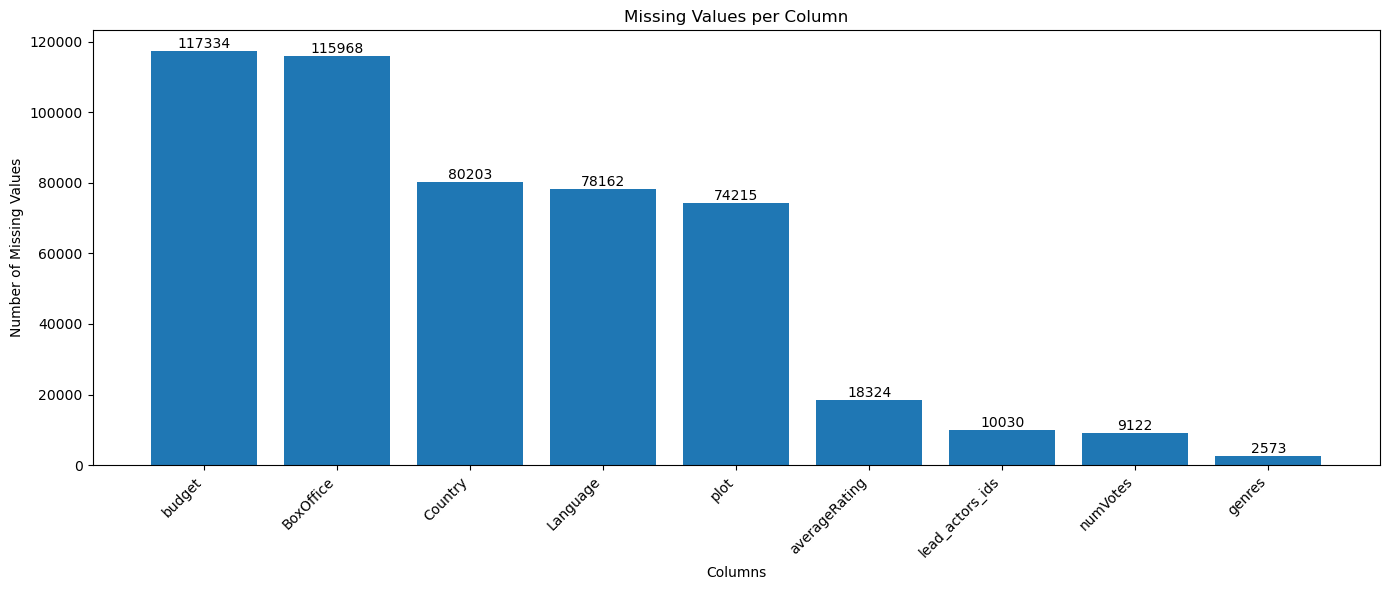

In [7]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values = missing_values.sort_values(ascending=False)

plt.figure(figsize=(14, 6))
bars = plt.bar(missing_values.index, missing_values.values)


for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of Missing Values')
plt.xlabel('Columns')
plt.title('Missing Values per Column')

plt.tight_layout()
plt.show()

## Part 2 -  Analysis of Main Values Across Features

### 2.1 - language

In [9]:
def split_language_cell(value):
    if pd.isna(value):
        return []

    if isinstance(value, list):
        items = value
    else:
        text = str(value).strip()

        try:
            parsed = ast.literal_eval(text)
            if isinstance(parsed, list):
                items = parsed
            else:
                items = [text]
        except:
            items = re.split(r'\||/|,| and ', text)

    cleaned = []

    for item in items:
        item = str(item).strip()
        item = re.sub(r'\[.*?\]', '', item)
        item = re.sub(r'\(.*?\)', '', item)
        item = item.strip()

        if item != '':
            cleaned.append(item)

    return cleaned



language_df = df[['Language']].copy()

language_df['Language_split'] = language_df['Language'].apply(split_language_cell)

languages_exploded = language_df.explode('Language_split')

language_counts_raw = (
    languages_exploded['Language_split']
    .dropna()
    .value_counts()
    .reset_index()
)

language_counts_raw.columns = ['language_raw', 'count']

language_counts_raw.head(15)

,language_raw,count
0,English,27499
1,French,2590
2,Hindi,2428
3,Spanish,2201
4,Italian,1979
5,Not Found,1645
6,Japanese,1585
7,Tamil,1325
8,German,1316
9,Telugu,1056


## Part 3 - Building prepare_data function

### Step 1: Remove rows with missing target variable

In [35]:
def prepare_data(df):
    df = df.copy()

    # Step 1: Clean target variable
    if 'averageRating' in df.columns:

        # Convert target column to numeric
        df['averageRating'] = pd.to_numeric(
            df['averageRating'],
            errors='coerce'
        )

        # Remove missing / invalid target values
        df = df.dropna(subset=['averageRating'])

    return df

##### Tracking the results

In [38]:
df_prepared = prepare_data(df)

In [40]:
# Number of movies (rows) and columns
print(f"Dataset shape: {df_prepared.shape}")

print(f"\nNumber of movies: {df_prepared.shape[0]}")
print(f"Number of columns: {df_prepared.shape[1]}")

# Missing values per column
missing_values = df_prepared.isnull().sum()

# Sort from highest to lowest
missing_values = missing_values.sort_values(ascending=False)

print("\nMissing values per column:")
print(missing_values)

Dataset shape: (115560, 13)

Number of movies: 115560
Number of columns: 13

Missing values per column:
budget             99386
BoxOffice          98060
Country            63440
Language           61510
plot               58818
lead_actors_ids     6549
genres               846
tconst                 0
primaryTitle           0
startYear              0
runtimeMinutes         0
averageRating          0
numVotes               0
dtype: int64


### Step 2: Remove leakage columns

In [43]:
def prepare_data(df):
    df = df.copy()

    # Step 1: Clean target variable
    if 'averageRating' in df.columns:

        # Convert target column to numeric
        df['averageRating'] = pd.to_numeric(
            df['averageRating'],
            errors='coerce'
        )

        # Remove missing / invalid target values
        df = df.dropna(subset=['averageRating'])

    # Step 2: Remove leakage columns
    leakage_cols = ['numVotes', 'BoxOffice']

    for col in leakage_cols:

        # Remove column only if it exists
        if col in df.columns:
            df = df.drop(columns=col)

    return df

##### Tracking the results

In [46]:
df_prepared = prepare_data(df)

In [48]:
print(f"Dataset shape: {df_prepared.shape}")

print(f"\nNumber of movies: {df_prepared.shape[0]}")
print(f"Number of columns: {df_prepared.shape[1]}")

# Missing values per column
missing_values = df_prepared.isnull().sum()

# Sort from highest to lowest
missing_values = missing_values.sort_values(ascending=False)

print("\nMissing values per column:")
print(missing_values)

Dataset shape: (115560, 11)

Number of movies: 115560
Number of columns: 11

Missing values per column:
budget             99386
Country            63440
Language           61510
plot               58818
lead_actors_ids     6549
genres               846
tconst                 0
primaryTitle           0
startYear              0
runtimeMinutes         0
averageRating          0
dtype: int64


### Step 3: Basic missing values handling

In [51]:
def prepare_data(df):
    df = df.copy()

    # Step 1: Remove rows with missing target variable
    if 'averageRating' in df.columns:

        # Convert target to numeric
        df['averageRating'] = pd.to_numeric(
            df['averageRating'],
            errors='coerce'
        )

        # Remove invalid / missing target values
        df = df.dropna(subset=['averageRating'])

    # Step 2: Remove leakage columns
    leakage_cols = ['numVotes', 'BoxOffice']

    for col in leakage_cols:
        if col in df.columns:
            df = df.drop(columns=col)

    # Step 3: Basic missing values handling
    fill_values = {
        'Country': 'Unknown',
        'Language': 'Unknown',
        'plot': '',
        'genres': 'Unknown',
        'primaryTitle': 'Unknown'
    }

    for col, value in fill_values.items():
        if col in df.columns:
            df[col] = df[col].fillna(value)

    # Handle lead_actors_ids separately (empty list)
    if 'lead_actors_ids' in df.columns:
        df['lead_actors_ids'] = df['lead_actors_ids'].apply(
            lambda x: [] if pd.isna(x) else x
        )

    return df

##### Tracking the results

In [54]:
df_prepared = prepare_data(df)

In [55]:
print(f"Dataset shape: {df_prepared.shape}")

print(f"\nNumber of movies: {df_prepared.shape[0]}")
print(f"Number of columns: {df_prepared.shape[1]}")

# Missing values per column
missing_values = df_prepared.isnull().sum()

# Sort from highest to lowest
missing_values = missing_values.sort_values(ascending=False)

print("\nMissing values per column:")
print(missing_values)

Dataset shape: (115560, 11)

Number of movies: 115560
Number of columns: 11

Missing values per column:
budget             99386
tconst                 0
primaryTitle           0
startYear              0
genres                 0
lead_actors_ids        0
runtimeMinutes         0
averageRating          0
Language               0
Country                0
plot                   0
dtype: int64


### Step 4: Feature Engineering

#### Step 4.1 - Plot word count

In [94]:
def prepare_data(df):
    df = df.copy()

    # Step 1: Remove rows with missing target variable
    if 'averageRating' in df.columns:

        # Convert target to numeric
        df['averageRating'] = pd.to_numeric(
            df['averageRating'],
            errors='coerce'
        )

        # Remove invalid / missing target values
        df = df.dropna(subset=['averageRating'])

    # Step 2: Remove leakage columns
    leakage_cols = ['numVotes', 'BoxOffice']

    for col in leakage_cols:
        if col in df.columns:
            df = df.drop(columns=col)

    # Step 3: Basic missing values handling
    fill_values = {
        'Country': 'Unknown',
        'Language': 'Unknown',
        'plot': '',
        'genres': 'Unknown',
        'primaryTitle': 'Unknown'
    }

    for col, value in fill_values.items():
        if col in df.columns:
            df[col] = df[col].fillna(value)

    # Handle lead_actors_ids separately (empty list)
    if 'lead_actors_ids' in df.columns:
        df['lead_actors_ids'] = df['lead_actors_ids'].apply(
            lambda x: [] if pd.isna(x) else x
        )

    # Step 4: Feature Engineering

    # Feature 1: Plot word count
    if 'plot' in df.columns:
        df['plot_word_count'] = df['plot'].apply(
            lambda x: len(str(x).split())
        )

    return df

##### Tracking the results

In [96]:
df_prepared = prepare_data(df)
df_prepared[
    (df_prepared['plot_word_count'] > 0) &
    (df_prepared['plot_word_count'] < 10)
][['plot', 'plot_word_count']].head(10)

,plot,plot_word_count
17599,Music was composed by Deva.[3],5
18453,A deranged young tailor descends into madness ...,9
18505,The film's music is composed by Kranthi Achary...,9
18693,Plot description missing,3
18718,Plot description missing,3
18759,Plot description missing,3
18762,Plot description missing,3
18889,Plot description missing,3
18947,Plot description missing,3
19007,Plot description missing,3


#### Step 4.2 - Decade

In [98]:
def prepare_data(df):
    df = df.copy()

    # Step 1: Remove rows with missing / invalid target variable
    if 'averageRating' in df.columns:

        df['averageRating'] = pd.to_numeric(
            df['averageRating'],
            errors='coerce'
        )

        df = df.dropna(subset=['averageRating'])

    # Step 2: Remove leakage columns
    leakage_cols = ['numVotes', 'BoxOffice']

    for col in leakage_cols:
        if col in df.columns:
            df = df.drop(columns=col)

    # Step 3: Basic missing values handling
    fill_values = {
        'Country': 'Unknown',
        'Language': 'Unknown',
        'plot': '',
        'genres': 'Unknown',
        'primaryTitle': 'Unknown'
    }

    for col, value in fill_values.items():
        if col in df.columns:
            df[col] = df[col].fillna(value)

    # Handle lead_actors_ids separately
    if 'lead_actors_ids' in df.columns:
        df['lead_actors_ids'] = df['lead_actors_ids'].apply(
            lambda x: [] if pd.isna(x) else x
        )

    # Step 4: Feature Engineering

    # Feature 1: Plot word count
    if 'plot' in df.columns:
        df['plot_word_count'] = df['plot'].apply(
            lambda x: len(str(x).strip().split())
        )

    # Feature 2: Release decade
    if 'startYear' in df.columns:
        df['startYear'] = pd.to_numeric(
            df['startYear'],
            errors='coerce'
        )

        df['decade'] = (df['startYear'] // 10) * 10

    return df

##### Tracking the results

In [100]:
df_prepared = prepare_data(df)

In [102]:
df_prepared.head()

,tconst,primaryTitle,startYear,genres,lead_actors_ids,runtimeMinutes,averageRating,Language,Country,budget,plot,plot_word_count,decade
0,tt0107274,Johnny One Hundred Pesos,1993.0,"Crime,Drama,Thriller","['nm0032843', 'nm0729381', 'nm0783839', 'nm066...",90.0,6.6,Spanish,Chile,NaN,,0,1990.0
1,tt32133209,It Doesn't Matter,2024.0,Drama,"['nm3571592', 'nm6238285', 'nm2541664', 'nm161...",86.0,6.1,Unknown,Unknown,NaN,,0,2020.0
4,tt0765142,"If You Love Me, Follow Me",2006.0,Comedy,"['nm0218843', 'nm0693844', 'nm0220017', 'nm000...",102.0,6.1,Unknown,Unknown,NaN,,0,2000.0
7,tt1872082,I Want My Name Back,2011.0,"Biography,Documentary,Music",[],85.0,7.0,Unknown,Unknown,NaN,,0,2010.0
8,tt0190489,Itgaber: Le triomphe sur soi,1993.0,Documentary,[],170.0,9.2,Unknown,Unknown,NaN,,0,1990.0


#### Step 4.3 - Number of lead actors

In [104]:
def prepare_data(df):
    df = df.copy()

    # Step 1: Remove rows with missing / invalid target variable
    if 'averageRating' in df.columns:

        # Convert target to numeric
        df['averageRating'] = pd.to_numeric(
            df['averageRating'],
            errors='coerce'
        )

        # Remove invalid / missing target values
        df = df.dropna(subset=['averageRating'])

    # Step 2: Remove leakage columns
    leakage_cols = ['numVotes', 'BoxOffice']

    for col in leakage_cols:
        if col in df.columns:
            df = df.drop(columns=col)

    # Step 3: Basic missing values handling
    fill_values = {
        'Country': 'Unknown',
        'Language': 'Unknown',
        'plot': '',
        'genres': 'Unknown',
        'primaryTitle': 'Unknown'
    }

    for col, value in fill_values.items():
        if col in df.columns:
            df[col] = df[col].fillna(value)

    # Handle lead_actors_ids separately
    if 'lead_actors_ids' in df.columns:
        df['lead_actors_ids'] = df['lead_actors_ids'].apply(
            lambda x: [] if pd.isna(x) else x
        )

    # Step 4: Feature Engineering

    # Feature 1: Plot word count
    if 'plot' in df.columns:
        df['plot_word_count'] = df['plot'].apply(
            lambda x: len(str(x).strip().split())
        )

    # Feature 2: Release decade
    if 'startYear' in df.columns:

        # Convert startYear to numeric
        df['startYear'] = pd.to_numeric(
            df['startYear'],
            errors='coerce'
        )

        # Create decade feature
        df['decade'] = (
            (df['startYear'] // 10) * 10
        )

    # Feature 3: Number of lead actors
    if 'lead_actors_ids' in df.columns:

        def count_lead_actors(value):

            # Case 1: already a list
            if isinstance(value, list):
                return len(value)

            # Convert value to string
            text = str(value).strip()

            # Empty / invalid values
            if text in ['', '[]', '\\N']:
                return 0

            # Case 2: separated by commas
            if ',' in text:

                split_values = [
                    item.strip()
                    for item in text.split(',')
                    if item.strip() != ''
                ]

                return len(split_values)

            # Case 3: separated by spaces
            if ' ' in text:

                split_values = [
                    item.strip()
                    for item in text.split()
                    if item.strip() != ''
                ]

                return len(split_values)

            # No valid separator found
            return 0

        df['num_lead_actors'] = df['lead_actors_ids'].apply(
            count_lead_actors
        )

    return df

##### Tracking the results

In [106]:
df_prepared = prepare_data(df)

df_prepared[
    (df_prepared['num_lead_actors'] > 0) &
    (df_prepared['num_lead_actors'] < 4)
].head()

,tconst,primaryTitle,startYear,genres,lead_actors_ids,runtimeMinutes,averageRating,Language,Country,budget,plot,plot_word_count,decade,num_lead_actors
16,tt11010804,Jesus,2020.0,Drama,"['nm2639110', 'nm4803342']",130.0,4.7,Unknown,Unknown,NaN,,0,2020.0,2
78,tt22507554,J005311,2022.0,Crime,"['nm14114721', 'nm11287490']",93.0,4.3,Unknown,Unknown,NaN,,0,2020.0,2
103,tt0084156,It Came from Hollywood,1982.0,"Comedy,Documentary","['nm0138787', 'nm0791698', 'nm0630076']",80.0,5.8,English,United States,NaN,,0,1980.0,3
215,tt14090546,Jamboo Savari,2014.0,Drama,"['nm5299622', 'nm6264784', 'nm12336849']",131.0,5.6,Unknown,Unknown,NaN,,0,2010.0,3
233,tt0485402,Jaque,2005.0,Unknown,"['nm2082271', 'nm2086427', 'nm1294410']",62.0,6.6,Unknown,Unknown,NaN,,0,2000.0,3


In [108]:
df_prepared = prepare_data(df)

df_prepared[
    df_prepared['num_lead_actors'] == 0
].head()

,tconst,primaryTitle,startYear,genres,lead_actors_ids,runtimeMinutes,averageRating,Language,Country,budget,plot,plot_word_count,decade,num_lead_actors
7,tt1872082,I Want My Name Back,2011.0,"Biography,Documentary,Music",[],85.0,7.0,Unknown,Unknown,NaN,,0,2010.0,0
8,tt0190489,Itgaber: Le triomphe sur soi,1993.0,Documentary,[],170.0,9.2,Unknown,Unknown,NaN,,0,1990.0,0
9,tt10797260,Journeys to the Edge of Consciousness,2019.0,"Adventure,Animation,Documentary",['nm6542718'],87.0,7.3,Unknown,Unknown,NaN,,0,2010.0,0
25,tt5271420,Jerome Lejeune - To the least of these my brot...,2015.0,Documentary,[],68.0,9.0,Unknown,Unknown,NaN,,0,2010.0,0
57,tt2526664,Italy in a Day,2014.0,Documentary,['nm9655052'],75.0,7.2,Unknown,Unknown,NaN,,0,2010.0,0


<span style="color:red">

IMPORTANT BUG:  
A bug was identified in the code: when `lead_actors_ids` contains a list with only one actor, the function returns `0` instead of `1`.

</span>

#### Fixing the bug

In [110]:
def prepare_data(df):
    df = df.copy()

    # Step 1: Remove rows with missing / invalid target variable
    if 'averageRating' in df.columns:

        # Convert target to numeric
        df['averageRating'] = pd.to_numeric(
            df['averageRating'],
            errors='coerce'
        )

        # Remove invalid / missing target values
        df = df.dropna(subset=['averageRating'])

    # Step 2: Remove leakage columns
    leakage_cols = ['numVotes', 'BoxOffice']

    for col in leakage_cols:
        if col in df.columns:
            df = df.drop(columns=col)

    # Step 3: Basic missing values handling
    fill_values = {
        'Country': 'Unknown',
        'Language': 'Unknown',
        'plot': '',
        'genres': 'Unknown',
        'primaryTitle': 'Unknown'
    }

    for col, value in fill_values.items():
        if col in df.columns:
            df[col] = df[col].fillna(value)

    # Handle lead_actors_ids separately
    if 'lead_actors_ids' in df.columns:
        df['lead_actors_ids'] = df['lead_actors_ids'].apply(
            lambda x: [] if pd.isna(x) else x
        )

    # Step 4: Feature Engineering

    # Feature 1: Plot word count
    if 'plot' in df.columns:
        df['plot_word_count'] = df['plot'].apply(
            lambda x: len(str(x).strip().split())
        )

    # Feature 2: Release decade
    if 'startYear' in df.columns:

        # Convert startYear to numeric
        df['startYear'] = pd.to_numeric(
            df['startYear'],
            errors='coerce'
        )

        # Create decade feature
        df['decade'] = (
            (df['startYear'] // 10) * 10
        )

       # Feature 3: Number of lead actors
    if 'lead_actors_ids' in df.columns:

        import ast

        def count_lead_actors(value):

            # Case 1: already a list
            if isinstance(value, list):
                return len(value)

            # Convert value to string
            text = str(value).strip()

            # Empty / invalid values
            if text in ['', '[]', '\\N']:
                return 0

            # Try converting string representation of list
            try:
                parsed = ast.literal_eval(text)

                if isinstance(parsed, list):
                    return len(parsed)

            except:
                pass

            # Case 2: separated by commas
            if ',' in text:

                split_values = [
                    item.strip()
                    for item in text.split(',')
                    if item.strip() != ''
                ]

                return len(split_values)

            # Case 3: separated by spaces
            if ' ' in text:

                split_values = [
                    item.strip()
                    for item in text.split()
                    if item.strip() != ''
                ]

                return len(split_values)

            # No valid separator found
            return 0

        df['num_lead_actors'] = df['lead_actors_ids'].apply(
            count_lead_actors
        )

    return df

##### Tracking the results

In [112]:
df_prepared = prepare_data(df)

df_prepared[
    df_prepared['num_lead_actors'] == 0
].head()

,tconst,primaryTitle,startYear,genres,lead_actors_ids,runtimeMinutes,averageRating,Language,Country,budget,plot,plot_word_count,decade,num_lead_actors
7,tt1872082,I Want My Name Back,2011.0,"Biography,Documentary,Music",[],85.0,7.0,Unknown,Unknown,NaN,,0,2010.0,0
8,tt0190489,Itgaber: Le triomphe sur soi,1993.0,Documentary,[],170.0,9.2,Unknown,Unknown,NaN,,0,1990.0,0
25,tt5271420,Jerome Lejeune - To the least of these my brot...,2015.0,Documentary,[],68.0,9.0,Unknown,Unknown,NaN,,0,2010.0,0
68,tt0892390,In the Family,2008.0,Documentary,[],83.0,8.0,Unknown,Unknown,NaN,,0,2000.0,0
73,tt1772925,Jiro Dreams of Sushi,2011.0,Documentary,[],81.0,7.8,Unknown,Unknown,NaN,,0,2010.0,0


In [114]:
df_prepared = prepare_data(df)

df_prepared[
    (df_prepared['num_lead_actors'] > 0) &
    (df_prepared['num_lead_actors'] < 5)
].head()

,tconst,primaryTitle,startYear,genres,lead_actors_ids,runtimeMinutes,averageRating,Language,Country,budget,plot,plot_word_count,decade,num_lead_actors
9,tt10797260,Journeys to the Edge of Consciousness,2019.0,"Adventure,Animation,Documentary",['nm6542718'],87.0,7.3,Unknown,Unknown,NaN,,0,2010.0,1
16,tt11010804,Jesus,2020.0,Drama,"['nm2639110', 'nm4803342']",130.0,4.7,Unknown,Unknown,NaN,,0,2020.0,2
57,tt2526664,Italy in a Day,2014.0,Documentary,['nm9655052'],75.0,7.2,Unknown,Unknown,NaN,,0,2010.0,1
71,tt0233938,Indrasabha,1932.0,Fantasy,"['nm0557645', 'nm0435321', 'nm0434115', 'nm006...",211.0,7.3,Unknown,Unknown,NaN,,0,1930.0,4
78,tt22507554,J005311,2022.0,Crime,"['nm14114721', 'nm11287490']",93.0,4.3,Unknown,Unknown,NaN,,0,2020.0,2


#### Step 4.4 - Number of lead actors

In [116]:
def prepare_data(df):
    df = df.copy()

    # Step 1: Remove rows with missing / invalid target variable
    if 'averageRating' in df.columns:

        # Convert target to numeric
        df['averageRating'] = pd.to_numeric(
            df['averageRating'],
            errors='coerce'
        )

        # Remove invalid / missing target values
        df = df.dropna(subset=['averageRating'])

    # Step 2: Remove leakage columns
    leakage_cols = ['numVotes', 'BoxOffice']

    for col in leakage_cols:
        if col in df.columns:
            df = df.drop(columns=col)

    # Step 3: Basic missing values handling
    fill_values = {
        'Country': 'Unknown',
        'Language': 'Unknown',
        'plot': '',
        'genres': 'Unknown',
        'primaryTitle': 'Unknown'
    }

    for col, value in fill_values.items():
        if col in df.columns:
            df[col] = df[col].fillna(value)

    # Handle lead_actors_ids separately
    if 'lead_actors_ids' in df.columns:
        df['lead_actors_ids'] = df['lead_actors_ids'].apply(
            lambda x: [] if pd.isna(x) else x
        )

    # Step 4: Feature Engineering

    # Feature 1: Plot word count
    if 'plot' in df.columns:
        df['plot_word_count'] = df['plot'].apply(
            lambda x: len(str(x).strip().split())
        )

    # Feature 2: Release decade
    if 'startYear' in df.columns:

        # Convert startYear to numeric
        df['startYear'] = pd.to_numeric(
            df['startYear'],
            errors='coerce'
        )

        # Create decade feature
        df['decade'] = (
            (df['startYear'] // 10) * 10
        )

    # Feature 3: Number of lead actors
    if 'lead_actors_ids' in df.columns:

        import ast

        def count_lead_actors(value):

            # Case 1: already a list
            if isinstance(value, list):
                return len(value)

            # Convert value to string
            text = str(value).strip()

            # Empty / invalid values
            if text in ['', '[]', '\\N']:
                return 0

            # Try converting string representation of list
            try:
                parsed = ast.literal_eval(text)

                if isinstance(parsed, list):
                    return len(parsed)

            except:
                pass

            # Case 2: separated by commas
            if ',' in text:

                split_values = [
                    item.strip()
                    for item in text.split(',')
                    if item.strip() != ''
                ]

                return len(split_values)

            # Case 3: separated by spaces
            if ' ' in text:

                split_values = [
                    item.strip()
                    for item in text.split()
                    if item.strip() != ''
                ]

                return len(split_values)

            # No valid separator found
            return 0

        df['num_lead_actors'] = df['lead_actors_ids'].apply(
            count_lead_actors
        )

    # Feature 4: Number of genres
    if 'genres' in df.columns:

        def count_genres(value):

            # Case 1: already a list
            if isinstance(value, list):
                return len(value)

            # Convert value to string
            text = str(value).strip()

            # Empty / invalid / unknown values
            if text in ['', '[]', '\\N', 'Unknown']:
                return 0

            # Try converting string representation of list
            try:
                parsed = ast.literal_eval(text)

                if isinstance(parsed, list):
                    return len(parsed)

            except:
                pass

            # Case 2: separated by commas
            if ',' in text:

                split_values = [
                    item.strip()
                    for item in text.split(',')
                    if item.strip() != ''
                ]

                return len(split_values)

            # Case 3: separated by spaces
            if ' ' in text:

                split_values = [
                    item.strip()
                    for item in text.split()
                    if item.strip() != ''
                ]

                return len(split_values)

            # Case 4: single known genre
            return 1

        df['num_genres'] = df['genres'].apply(
            count_genres
        )

    return df

##### Tracking the results

In [120]:
df_prepared = prepare_data(df)
df_prepared[
    df_prepared['num_genres'] > 0
].head()

,tconst,primaryTitle,startYear,genres,lead_actors_ids,runtimeMinutes,averageRating,Language,Country,budget,plot,plot_word_count,decade,num_lead_actors,num_genres
0,tt0107274,Johnny One Hundred Pesos,1993.0,"Crime,Drama,Thriller","['nm0032843', 'nm0729381', 'nm0783839', 'nm066...",90.0,6.6,Spanish,Chile,NaN,,0,1990.0,5,3
1,tt32133209,It Doesn't Matter,2024.0,Drama,"['nm3571592', 'nm6238285', 'nm2541664', 'nm161...",86.0,6.1,Unknown,Unknown,NaN,,0,2020.0,5,1
4,tt0765142,"If You Love Me, Follow Me",2006.0,Comedy,"['nm0218843', 'nm0693844', 'nm0220017', 'nm000...",102.0,6.1,Unknown,Unknown,NaN,,0,2000.0,5,1
7,tt1872082,I Want My Name Back,2011.0,"Biography,Documentary,Music",[],85.0,7.0,Unknown,Unknown,NaN,,0,2010.0,0,3
8,tt0190489,Itgaber: Le triomphe sur soi,1993.0,Documentary,[],170.0,9.2,Unknown,Unknown,NaN,,0,1990.0,0,1


In [122]:
df_prepared[
    df_prepared['num_genres'] == 0
].head()

,tconst,primaryTitle,startYear,genres,lead_actors_ids,runtimeMinutes,averageRating,Language,Country,budget,plot,plot_word_count,decade,num_lead_actors,num_genres
81,tt0155756,Ill Fares the Land,1983.0,Unknown,"['nm0103656', 'nm0178611', 'nm0222789', 'nm023...",102.0,7.6,Unknown,Unknown,NaN,,0,1980.0,5,0
98,tt0205157,Jiang hu er nu,1952.0,Unknown,"['nm2845780', 'nm3674428', 'nm2571853', 'nm367...",90.0,6.8,Unknown,Unknown,NaN,,0,1950.0,5,0
100,tt0184628,Jonás a Melicharová,1986.0,Unknown,"['nm0837098', 'nm0596440', 'nm0161616', 'nm042...",82.0,5.6,Unknown,Unknown,NaN,,0,1980.0,5,0
233,tt0485402,Jaque,2005.0,Unknown,"['nm2082271', 'nm2086427', 'nm1294410']",62.0,6.6,Unknown,Unknown,NaN,,0,2000.0,3,0
321,tt0131452,Inside the Mind,1998.0,Unknown,"['nm11525000', 'nm11525001']",89.0,6.7,Unknown,Unknown,NaN,,0,1990.0,2,0


### Step 4.5 - is_english

In [124]:
def prepare_data(df):
    df = df.copy()

    # Step 1: Remove rows with missing / invalid target variable
    if 'averageRating' in df.columns:

        # Convert target to numeric
        df['averageRating'] = pd.to_numeric(
            df['averageRating'],
            errors='coerce'
        )

        # Remove invalid / missing target values
        df = df.dropna(subset=['averageRating'])

    # Step 2: Remove leakage columns
    leakage_cols = ['numVotes', 'BoxOffice']

    for col in leakage_cols:
        if col in df.columns:
            df = df.drop(columns=col)

    # Step 3: Basic missing values handling
    fill_values = {
        'Country': 'Unknown',
        'Language': 'Unknown',
        'plot': '',
        'genres': 'Unknown',
        'primaryTitle': 'Unknown'
    }

    for col, value in fill_values.items():
        if col in df.columns:
            df[col] = df[col].fillna(value)

    # Handle lead_actors_ids separately
    if 'lead_actors_ids' in df.columns:
        df['lead_actors_ids'] = df['lead_actors_ids'].apply(
            lambda x: [] if pd.isna(x) else x
        )

    # Step 4: Feature Engineering

    # Feature 1: Plot word count
    if 'plot' in df.columns:
        df['plot_word_count'] = df['plot'].apply(
            lambda x: len(str(x).strip().split())
        )

    # Feature 2: Release decade
    if 'startYear' in df.columns:

        # Convert startYear to numeric
        df['startYear'] = pd.to_numeric(
            df['startYear'],
            errors='coerce'
        )

        # Create decade feature
        df['decade'] = (
            (df['startYear'] // 10) * 10
        )

    # Feature 3: Number of lead actors
    if 'lead_actors_ids' in df.columns:

        import ast

        def count_lead_actors(value):

            # Case 1: already a list
            if isinstance(value, list):
                return len(value)

            # Convert value to string
            text = str(value).strip()

            # Empty / invalid values
            if text in ['', '[]', '\\N']:
                return 0

            # Try converting string representation of list
            try:
                parsed = ast.literal_eval(text)

                if isinstance(parsed, list):
                    return len(parsed)

            except:
                pass

            # Case 2: separated by commas
            if ',' in text:

                split_values = [
                    item.strip()
                    for item in text.split(',')
                    if item.strip() != ''
                ]

                return len(split_values)

            # Case 3: separated by spaces
            if ' ' in text:

                split_values = [
                    item.strip()
                    for item in text.split()
                    if item.strip() != ''
                ]

                return len(split_values)

            # No valid separator found
            return 0

        df['num_lead_actors'] = df['lead_actors_ids'].apply(
            count_lead_actors
        )

    # Feature 4: Number of genres
    if 'genres' in df.columns:

        def count_genres(value):

            # Case 1: already a list
            if isinstance(value, list):
                return len(value)

            # Convert value to string
            text = str(value).strip()

            # Empty / invalid / unknown values
            if text in ['', '[]', '\\N', 'Unknown']:
                return 0

            # Try converting string representation of list
            try:
                parsed = ast.literal_eval(text)

                if isinstance(parsed, list):
                    return len(parsed)

            except:
                pass

            # Case 2: separated by commas
            if ',' in text:

                split_values = [
                    item.strip()
                    for item in text.split(',')
                    if item.strip() != ''
                ]

                return len(split_values)

            # Case 3: separated by spaces
            if ' ' in text:

                split_values = [
                    item.strip()
                    for item in text.split()
                    if item.strip() != ''
                ]

                return len(split_values)

            # Case 4: single known genre
            return 1

        df['num_genres'] = df['genres'].apply(
            count_genres
        )

    # Feature 5: is_english
    if 'Language' in df.columns:

        def is_english(value):

            # Case 1: list -> convert to string
            if isinstance(value, list):
                text = ' '.join(map(str, value))

            # Case 2: string
            elif isinstance(value, str):
                text = value

            # Case 3: any other type
            else:
                return 0

            # Clean text
            text = text.strip().lower()

            # Check if contains english
            if 'english' in text:
                return 1

            return 0

        df['is_english'] = df['Language'].apply(
            is_english
        )

    return df

##### Tracking the results

In [126]:
df_prepared = prepare_data(df)
df_prepared[
    df_prepared['is_english'] == 0
].head()

,tconst,primaryTitle,startYear,genres,lead_actors_ids,runtimeMinutes,averageRating,Language,Country,budget,plot,plot_word_count,decade,num_lead_actors,num_genres,is_english
0,tt0107274,Johnny One Hundred Pesos,1993.0,"Crime,Drama,Thriller","['nm0032843', 'nm0729381', 'nm0783839', 'nm066...",90.0,6.6,Spanish,Chile,NaN,,0,1990.0,5,3,0
1,tt32133209,It Doesn't Matter,2024.0,Drama,"['nm3571592', 'nm6238285', 'nm2541664', 'nm161...",86.0,6.1,Unknown,Unknown,NaN,,0,2020.0,5,1,0
4,tt0765142,"If You Love Me, Follow Me",2006.0,Comedy,"['nm0218843', 'nm0693844', 'nm0220017', 'nm000...",102.0,6.1,Unknown,Unknown,NaN,,0,2000.0,5,1,0
7,tt1872082,I Want My Name Back,2011.0,"Biography,Documentary,Music",[],85.0,7.0,Unknown,Unknown,NaN,,0,2010.0,0,3,0
8,tt0190489,Itgaber: Le triomphe sur soi,1993.0,Documentary,[],170.0,9.2,Unknown,Unknown,NaN,,0,1990.0,0,1,0


In [128]:
df_prepared[
    df_prepared['is_english'] == 1
].head()

,tconst,primaryTitle,startYear,genres,lead_actors_ids,runtimeMinutes,averageRating,Language,Country,budget,plot,plot_word_count,decade,num_lead_actors,num_genres,is_english
13,tt0102103,Impromptu,1991.0,"Biography,Comedy,Music","['nm0001114', 'nm0000424', 'nm0001597', 'nm000...",107.0,6.8,English,United Kingdom United States,NaN,,0,1990.0,5,3,1
40,tt0061827,It's a Bikini World,1967.0,"Comedy,Musical","['nm0909117', 'nm0456565', 'nm0456565', 'nm068...",86.0,4.7,English,United States,NaN,,0,1960.0,5,2,1
59,tt0008144,Jack and the Beanstalk,1917.0,Fantasy,"['nm0139333', 'nm0139333', 'nm0179247', 'nm017...",100.0,4.2,Silent (English intertitles ),United States,NaN,,0,1910.0,5,1,1
93,tt0030303,Juvenile Court,1938.0,"Action,Crime,Drama","['nm0446769', 'nm0000028', 'nm0201660', 'nm015...",60.0,5.8,English,United States,NaN,,0,1930.0,5,3,1
103,tt0084156,It Came from Hollywood,1982.0,"Comedy,Documentary","['nm0138787', 'nm0791698', 'nm0630076']",80.0,5.8,English,United States,NaN,,0,1980.0,3,2,1


## Final prepare_data function

In [ ]:
def prepare_data(df):
    df = df.copy()

    # Step 1: Remove rows with missing / invalid target variable
    if 'averageRating' in df.columns:

        # Convert target to numeric
        df['averageRating'] = pd.to_numeric(
            df['averageRating'],
            errors='coerce'
        )

        # Remove invalid / missing target values
        df = df.dropna(subset=['averageRating'])

    # Step 2: Remove leakage columns
    leakage_cols = ['numVotes', 'BoxOffice']

    for col in leakage_cols:
        if col in df.columns:
            df = df.drop(columns=col)

    # Step 3: Basic missing values handling
    fill_values = {
        'Country': 'Unknown',
        'Language': 'Unknown',
        'plot': '',
        'genres': 'Unknown',
        'primaryTitle': 'Unknown'
    }

    for col, value in fill_values.items():
        if col in df.columns:
            df[col] = df[col].fillna(value)

    # Handle lead_actors_ids separately
    if 'lead_actors_ids' in df.columns:
        df['lead_actors_ids'] = df['lead_actors_ids'].apply(
            lambda x: [] if pd.isna(x) else x
        )

    # Step 4: Feature Engineering

    # Feature 1: Plot word count
    if 'plot' in df.columns:
        df['plot_word_count'] = df['plot'].apply(
            lambda x: len(str(x).strip().split())
        )

    # Feature 2: Release decade
    if 'startYear' in df.columns:

        # Convert startYear to numeric
        df['startYear'] = pd.to_numeric(
            df['startYear'],
            errors='coerce'
        )

        # Create decade feature
        df['decade'] = (
            (df['startYear'] // 10) * 10
        )

    # Feature 3: Number of lead actors
    if 'lead_actors_ids' in df.columns:

        import ast

        def count_lead_actors(value):

            # Case 1: already a list
            if isinstance(value, list):
                return len(value)

            # Convert value to string
            text = str(value).strip()

            # Empty / invalid values
            if text in ['', '[]', '\\N']:
                return 0

            # Try converting string representation of list
            try:
                parsed = ast.literal_eval(text)

                if isinstance(parsed, list):
                    return len(parsed)

            except:
                pass

            # Case 2: separated by commas
            if ',' in text:

                split_values = [
                    item.strip()
                    for item in text.split(',')
                    if item.strip() != ''
                ]

                return len(split_values)

            # Case 3: separated by spaces
            if ' ' in text:

                split_values = [
                    item.strip()
                    for item in text.split()
                    if item.strip() != ''
                ]

                return len(split_values)

            # No valid separator found
            return 0

        df['num_lead_actors'] = df['lead_actors_ids'].apply(
            count_lead_actors
        )

    # Feature 4: Number of genres
    if 'genres' in df.columns:

        def count_genres(value):

            # Case 1: already a list
            if isinstance(value, list):
                return len(value)

            # Convert value to string
            text = str(value).strip()

            # Empty / invalid / unknown values
            if text in ['', '[]', '\\N', 'Unknown']:
                return 0

            # Try converting string representation of list
            try:
                parsed = ast.literal_eval(text)

                if isinstance(parsed, list):
                    return len(parsed)

            except:
                pass

            # Case 2: separated by commas
            if ',' in text:

                split_values = [
                    item.strip()
                    for item in text.split(',')
                    if item.strip() != ''
                ]

                return len(split_values)

            # Case 3: separated by spaces
            if ' ' in text:

                split_values = [
                    item.strip()
                    for item in text.split()
                    if item.strip() != ''
                ]

                return len(split_values)

            # Case 4: single known genre
            return 1

        df['num_genres'] = df['genres'].apply(
            count_genres
        )

    # Feature 5: is_english
    if 'Language' in df.columns:

        def is_english(value):

            # Case 1: list -> convert to string
            if isinstance(value, list):
                text = ' '.join(map(str, value))

            # Case 2: string
            elif isinstance(value, str):
                text = value

            # Case 3: any other type
            else:
                return 0

            # Clean text
            text = text.strip().lower()

            # Check if contains english
            if 'english' in text:
                return 1

            return 0

        df['is_english'] = df['Language'].apply(
            is_english
        )

    return df

In [ ]:
# הערה עשינו היערה חתכנו קצת מהדאטה וחירבשנו ערכים לבדוק באגים והפונקציה עובדת חלק